Custom Optimizers (Momentum, RMSprop, Adam)

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

Generate Dataset

In [2]:
torch.manual_seed(42)

X = torch.randn(200, 2)
Y = (X[:,0]**2 + X[:,1] > 0).float().view(-1,1)

 Initialize Parameters

In [3]:
W = torch.randn(2,1)
b = torch.zeros(1)

learning_rate = 0.01
epochs = 100

# Choose Optimizer
optimizer = "Adam"     # Momentum / RMSprop / Adam

Initialize Variables

In [4]:
velocity_W = torch.zeros_like(W)
velocity_b = torch.zeros_like(b)

cache_W = torch.zeros_like(W)
cache_b = torch.zeros_like(b)

mW = torch.zeros_like(W)
mb = torch.zeros_like(b)

vW = torch.zeros_like(W)
vb = torch.zeros_like(b)

beta = 0.9
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8

loss_history = []

Sigmoid Function

In [5]:
def sigmoid(z):
    return 1 / (1 + torch.exp(-z))

Training Loop

In [6]:
for epoch in range(1, epochs+1):

    # Forward Pass
    Z = torch.matmul(X, W) + b
    A = sigmoid(Z)

    # Binary Cross Entropy Loss
    loss = -torch.mean(
        Y * torch.log(A + 1e-8) +
        (1-Y) * torch.log(1-A + 1e-8)
    )

    loss_history.append(loss.item())

    # Backward (Manual)
    dZ = A - Y
    dW = torch.matmul(X.T, dZ) / len(X)
    db = torch.mean(dZ)


Momentum Optimizer

In [7]:
if optimizer == "Momentum":

        velocity_W = beta*velocity_W + (1-beta)*dW
        velocity_b = beta*velocity_b + (1-beta)*db

        W -= learning_rate * velocity_W
        b -= learning_rate * velocity_b

In [9]:
if optimizer == "RMSprop":

        cache_W = beta*cache_W + (1-beta)*(dW**2)
        cache_b = beta*cache_b + (1-beta)*(db**2)

        W -= learning_rate * dW / (torch.sqrt(cache_W)+epsilon)
        b -= learning_rate * db / (torch.sqrt(cache_b)+epsilon)

Adam Optimizer

In [12]:
if optimizer == "Adam":

        mW = beta1*mW + (1-beta1)*dW
        mb = beta1*mb + (1-beta1)*db

        vW = beta2*vW + (1-beta2)*(dW**2)
        vb = beta2*vb + (1-beta2)*(db**2)

        mW_hat = mW / (1-beta1**epoch)
        mb_hat = mb / (1-beta1**epoch)

        vW_hat = vW / (1-beta2**epoch)
        vb_hat = vb / (1-beta2**epoch)

        W -= learning_rate * mW_hat / (torch.sqrt(vW_hat)+epsilon)
        b -= learning_rate * mb_hat / (torch.sqrt(vb_hat)+epsilon)

        if epoch % 10 == 0:
            print(f"Epoch {epoch} Loss = {loss.item():.4f}")

Epoch 100 Loss = 0.9683


Plot Loss Curve


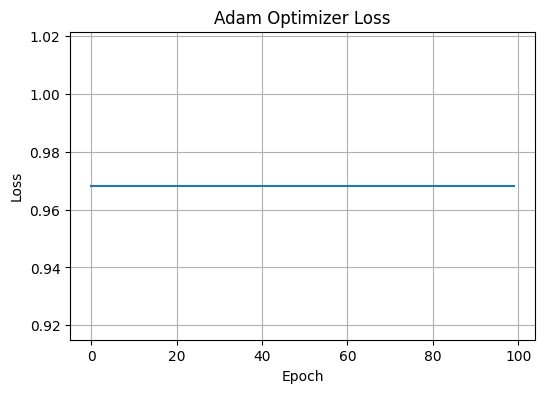

In [14]:
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title(f"{optimizer} Optimizer Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


Final Parameters

In [13]:
print("\nFinal Weight:")
print(W)

print("\nFinal Bias:")
print(b)


Final Weight:
tensor([[ 0.6318],
        [-0.5866]])

Final Bias:
tensor([0.0098])
